# macro.py — Daily OHLC Volume/Volatility Exploration

**Purpose:** Test, on free daily data, whether high-volume days on SPY show a
wider-than-normal price range, and whether the close tends to hold near the
day's extreme (sustained move) or drift back toward the middle (round-trip /
faded move). This is the coarse, macro-level pass before any intraday work.

**Data:** SPY daily OHLCV via yfinance, free, no API key needed.

**Design choices (flag if you want these changed):**
- "Volatility" here = standard deviation of daily *log returns*, annualized
  by multiplying by sqrt(252) trading days. This is the standard "realized
  volatility" definition used in finance — not the raw stdev of price levels.
- "Variance" = the same log-return series, squared units (std² = variance).
  Variance isn't very interpretable on its own; std (volatility) is the
  number people actually quote (e.g. "SPY realized vol is 13%").
- Full window: 2023-01-01 to 2025-12-31 (past two years, per your spec).
- Explore period: 2023-01-01 to 2024-12-31 (used to look for a pattern).
- Held-back test period: 2025-01-01 to 2025-12-31 (untouched until you're
  ready to test a *final* version of the rule — do not peek early).

**Total code: ~50 lines across 2 cells, per your spec.**


[*********************100%***********************]  1 of 1 completed


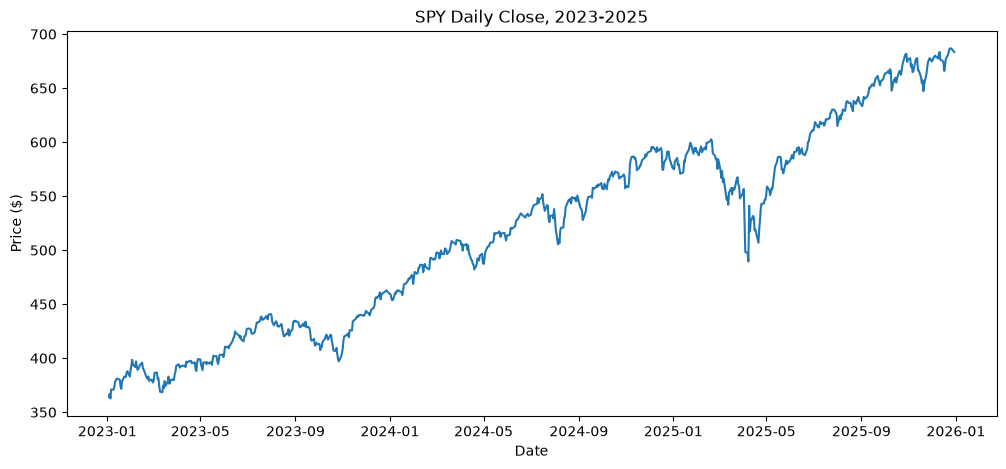

TypeError: unsupported format string passed to Series.__format__

In [3]:
# --- Block 1: fetch data, plot, compute volume + volatility ---
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fetch SPY daily OHLCV, 2021-2023
spy = yf.download("SPY", start="2023-01-01", end="2025-12-31")
spy = spy[["Open", "High", "Low", "Close", "Volume"]].dropna()

# Plot price over the full period
plt.figure(figsize=(12, 5))
plt.plot(spy.index, spy["Close"])
plt.title("SPY Daily Close, 2023-2025")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

# Daily log returns (used for volatility, not raw price)
spy["LogReturn"] = np.log(spy["Close"] / spy["Close"].shift(1))

# Total volume over the full period
total_volume = spy["Volume"].sum()

# Variance and volatility (annualized) of daily returns
daily_variance = spy["LogReturn"].var()
daily_std = spy["LogReturn"].std()
annualized_vol = daily_std * np.sqrt(252)

print(f"Total volume 2023-2025: {total_volume:,.0f}")
print(f"Daily variance (log returns): {daily_variance:.6f}")
print(f"Daily std dev / volatility: {daily_std:.6f}")
print(f"Annualized volatility: {annualized_vol:.2%}")


In [ ]:
# --- Block 2: explore/holdback split + volume-vs-range hypothesis test ---
# Explore set (look for a pattern here) vs holdback (test once, don't peek early)
explore = spy.loc["2023-01-01":"2024-12-31"].copy()
holdback = spy.loc["2025-01-01":"2025-12-31"].copy()

# Daily range (as % of open) and a volume z-score vs trailing 20-day average
explore["Range"] = (explore["High"] - explore["Low"]) / explore["Open"]
vol_mean = explore["Volume"].rolling(20).mean()
vol_std = explore["Volume"].rolling(20).std()
explore["VolZ"] = (explore["Volume"] - vol_mean) / vol_std

# Flag high-volume days: volume > 1.5 std above its 20-day average
explore["HighVolDay"] = explore["VolZ"] > 1.5

# Where the close sits within the day's range: 1.0 = at the high, 0.0 = at the low
explore["ClosePosition"] = (explore["Close"] - explore["Low"]) / (explore["High"] - explore["Low"])

# Compare: do high-volume days have wider ranges, and does the close hold
# near an extreme (sustained) or drift to the middle (faded/round-trip)?
summary = explore.groupby("HighVolDay")[["Range", "ClosePosition"]].mean()
print(summary)
